In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.dm as dm
import esc_fresnel.esc_optics as esc_optics
import esc_fresnel.iefc as iefc

dm_flat = utils.load_fits('../data/esc_fresnel_dm_flat.fits')
dh_command = utils.load_fits('../data/esc_fresnel_dm_dh_command.fits')


In [3]:
amp_dir = '/npool/nvme/kianmilani/esc-wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/npool/nvme/kianmilani/esc-wfe-maps/6nm_surfPSD/'

wfe_optic = 12

# Ignore OAP7 So that doesn't add any WFE when we compute the flat
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

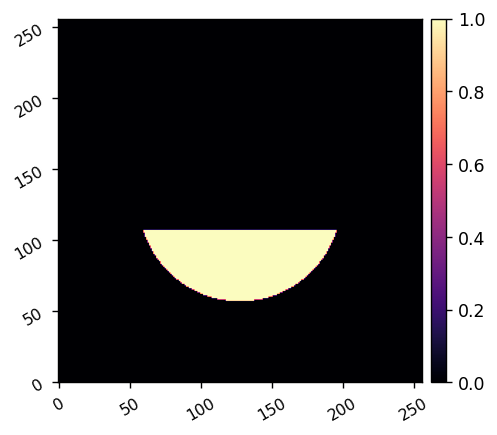

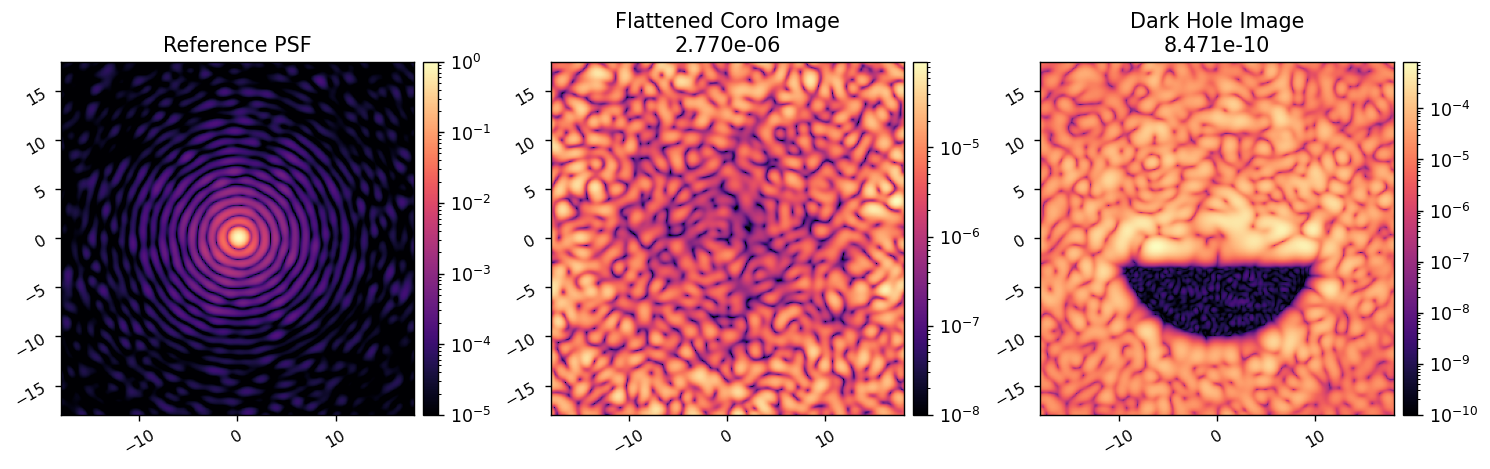

In [7]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 256

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
coro_im_flat = M.snap()

M.set_dm(dh_command, channel=3)
coro_im_dh = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.psf_pixelscale_lamD,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow1(coro_mask)

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow3(
    ref_psf/M.Imax_ref, coro_im_flat, coro_im_dh,
    # ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask,
    f'Reference PSF',
    f'Flattened Coro Image\n{contrast_flat:.3e}',
    f'Dark Hole Image\n{contrast_dh:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin1=1e-5, 
    vmin2=1e-8,
    vmin3=1e-10,
)

In [15]:
def snap_bb(M, waves):
    bb_im = 0.0
    for wave in waves:
        M.wavelength = wave
        mono_im = M.snap()
        bb_im += mono_im
    return bb_im

[6.33750e-07 6.41875e-07 6.50000e-07 6.58125e-07 6.66250e-07] m


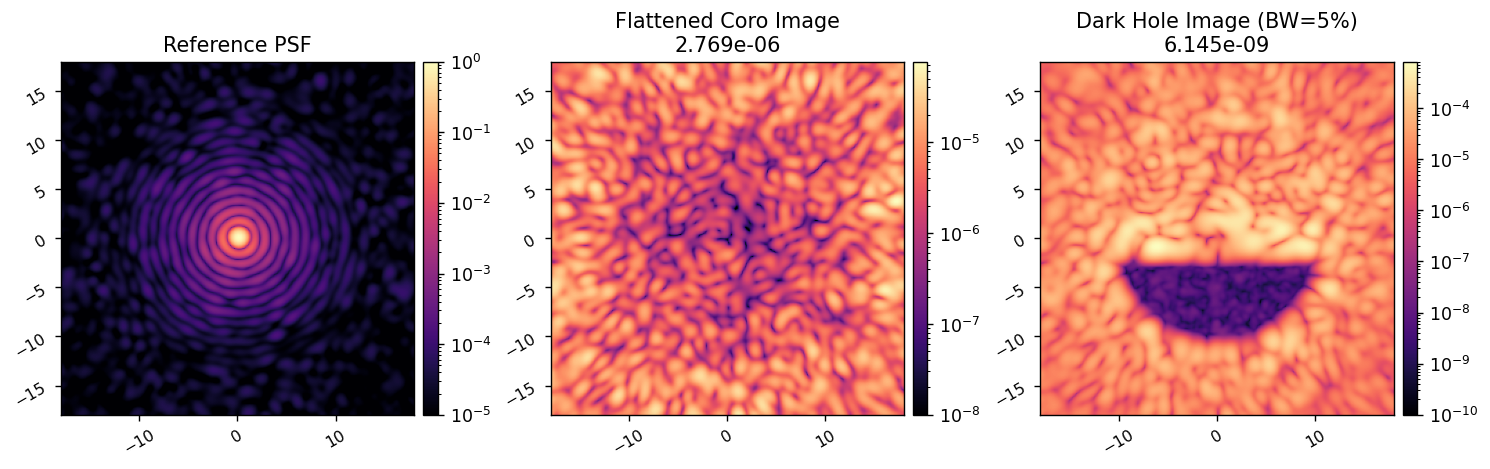

In [18]:
bw = 0.05
waves = np.linspace((1-bw/2)*M.wavelength_c, (1+bw/2)*M.wavelength_c, 5)
print(waves)

M.reset_dm()
M.use_vortex = False
ref_psf = snap_bb(M, waves)
Imax_ref = np.max(ref_psf)

M.use_vortex = True
coro_im_flat = snap_bb(M, waves) /Imax_ref

M.set_dm(dh_command, channel=3)
coro_im_dh = snap_bb(M, waves) /Imax_ref

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow3(
    ref_psf/Imax_ref, coro_im_flat, coro_im_dh,
    # ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask,
    f'Reference PSF',
    f'Flattened Coro Image\n{contrast_flat:.3e}',
    f'Dark Hole Image (BW={bw*100:.0f}%)\n{contrast_dh:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin1=1e-5, 
    vmin2=1e-8,
    vmin3=1e-10,
)

# Expected jitter/pointing error is 40mas before M4, 10mas bewteen M4 and FSM, and then 5mas for the rest.

# Perform an initial propagation to compute a reference PSF that is used to normalize the coronagraphic images. 

In [7]:
1.100000000000000E-001 + (50*u.mas).to(u.degree).value

0.11001388888888888

In [8]:
(50*u.mas).to(u.degree).value

1.3888888888888891e-05

In [5]:
start_row = 22
end_row = 128 - 22

surf_nums = np.loadtxt('../stppsf/esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=0, encoding="utf-16", dtype=int)

xc_on_axis = np.loadtxt('../stppsf/esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_on_axis = np.loadtxt('../stppsf/esc_ray_on_axis.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_50mas_x = np.loadtxt('../stppsf/esc_ray_50mas_x.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_50mas_x = np.loadtxt('../stppsf/esc_ray_50mas_x.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)

xc_50mas_y = np.loadtxt('../stppsf/esc_ray_50mas_y.txt', skiprows=start_row, max_rows=end_row, usecols=1, encoding="utf-16",)
yc_50mas_y = np.loadtxt('../stppsf/esc_ray_50mas_y.txt', skiprows=start_row, max_rows=end_row, usecols=2, encoding="utf-16",)



In [6]:
reload(esc_optics)

seed = 1234
optic_keys = list(esc_optics.zemax_inds.keys())
beamwalk_mats = {}
for i in range(len(optic_keys)):
    surf_num = esc_optics.zemax_inds[optic_keys[i]]
    surf_ind = np.where(surf_num==surf_nums)[0][0]
    print(optic_keys[i])
    print(surf_num, surf_ind)
    M_bw = np.array([
        [xc_on_axis[surf_ind] - xc_50mas_x[surf_ind], xc_on_axis[surf_ind] - xc_50mas_y[surf_ind]],
        [yc_on_axis[surf_ind] - yc_50mas_x[surf_ind], yc_on_axis[surf_ind] - yc_50mas_y[surf_ind]]
    ]) * u.mm/ (50*u.mas)
    print(M_bw)
    beamwalk_mats.update({optic_keys[i]: M_bw})


m1
4 3
[[5.79800001e-07 2.00000159e-10]
 [0.00000000e+00 5.80000001e-07]] mm / mas
m2
5 4
[[-3.63238000e-05  1.04000000e-07]
 [-2.20000004e-09 -3.65406000e-05]] mm / mas
m3
6 5
[[-3.919788e-04  1.548200e-06]
 [ 2.642000e-07 -3.928214e-04]] mm / mas
m4
9 8
[[ 2.4466e-07 -6.2476e-07]
 [-5.6646e-07 -3.4695e-06]] mm / mas
wcc_fp
12 11
[[4.80693020e-04 7.25300000e-06]
 [7.26830400e-06 4.87232774e-04]] mm / mas
oap1
21 20
[[ 6.6750016e-04 -1.6380400e-06]
 [-1.6088000e-06  6.6342340e-04]] mm / mas
fm1
23 22
[[ 4.89312e-04 -1.13638e-06]
 [-1.11340e-06  5.15166e-04]] mm / mas
pupil_mask
27 26
[[0. 0.]
 [0. 0.]] mm / mas
oap2
30 29
[[-2.03320000e-07  7.27453000e-05]
 [-7.33840682e-05  2.13684004e-07]] mm / mas
ifp1
32 31
[[-2.77506000e-07  9.88544336e-05]
 [-9.52932494e-05  2.78051388e-07]] mm / mas
oap3
35 34
[[-3.12920000e-07  1.10546600e-04]
 [-1.11392347e-04  3.25623850e-07]] mm / mas
fsm
38 37
[[0. 0.]
 [0. 0.]] mm / mas
fm2
41 40
[[ 0.00000000e+00  0.00000000e+00]
 [ 6.92671446e-05 -2.0538

In [11]:
pointing = np.array([-120, -120])*u.mas
beamwalk_mats['m3'].dot(pointing)

<Quantity [0.04685167, 0.04710686] mm>

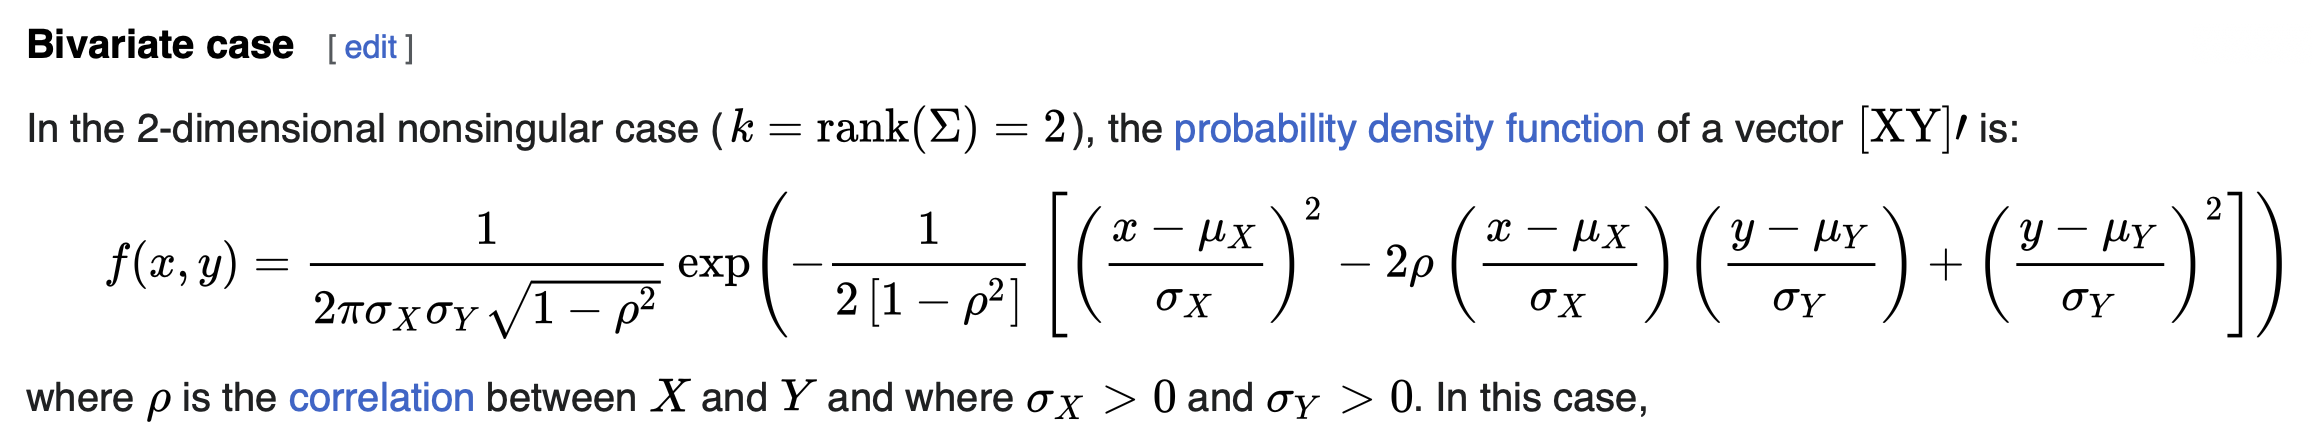


3600
(3600, 2)


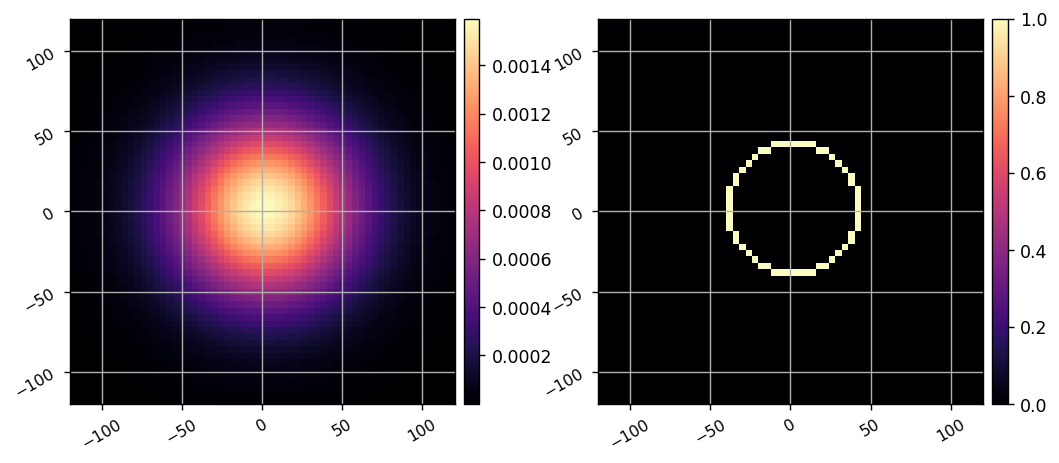

array(0.99456354)

In [7]:
jitter = 40*u.mas
pointing_sampling = 4*u.mas
Np = int(np.round( (6*jitter / pointing_sampling).decompose().value))
Nsamples = Np**2
print(Nsamples)

yc, xc = (xp.indices((Np, Np)) - Np//2)* pointing_sampling.to_value(u.mas)
rc = xp.sqrt(xc**2 + yc**2)
pdf_std = ( jitter.value-1.5 < rc ) * ( rc < jitter.value+2 )
pointing_samples = ensure_np_array ( xp.array([xc.flatten(), yc.flatten()]).T ) * u.mas
print(pointing_samples.shape)

amp = pointing_sampling.to_value(u.mas)**2 * 1/(2*xp.pi*jitter.to_value(u.mas)**2)
pointing_pdf = amp * xp.exp( -1/2 * ( (xc/jitter.to_value(u.mas))**2 + (yc/jitter.to_value(u.mas))**2 ) ) 
imshow2(pointing_pdf, pdf_std, 
        pxscl=pointing_sampling, grid=True)
xp.sum(pointing_pdf)

In [45]:
pointing_pdf.flatten()[1770]

array(0.00158361)

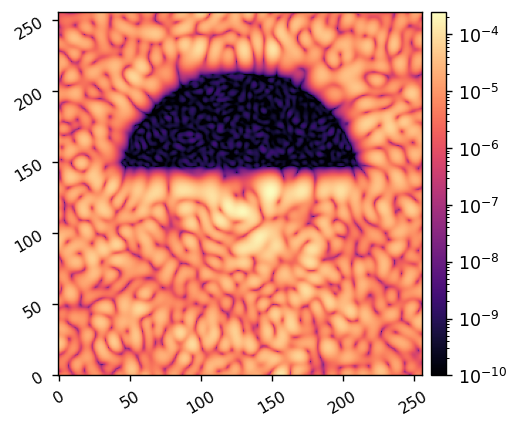

In [8]:
M.set_dm(dhc)
M.wfes = wfes
im = M.snap()
imshow1(im, lognorm=True, vmin=1e-10)

In [17]:
range(Nsamples)
np.arange(Nsamples)[::10]

array([   0,   10,   20,   30,   40,   50,   60,   70,   80,   90,  100,
        110,  120,  130,  140,  150,  160,  170,  180,  190,  200,  210,
        220,  230,  240,  250,  260,  270,  280,  290,  300,  310,  320,
        330,  340,  350,  360,  370,  380,  390,  400,  410,  420,  430,
        440,  450,  460,  470,  480,  490,  500,  510,  520,  530,  540,
        550,  560,  570,  580,  590,  600,  610,  620,  630,  640,  650,
        660,  670,  680,  690,  700,  710,  720,  730,  740,  750,  760,
        770,  780,  790,  800,  810,  820,  830,  840,  850,  860,  870,
        880,  890,  900,  910,  920,  930,  940,  950,  960,  970,  980,
        990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090,
       1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180, 1190, 1200,
       1210, 1220, 1230, 1240, 1250, 1260, 1270, 1280, 1290, 1300, 1310,
       1320, 1330, 1340, 1350, 1360, 1370, 1380, 1390, 1400, 1410, 1420,
       1430, 1440, 1450, 1460, 1470, 1480, 1490, 15

In [10]:
import time

M.set_dm(dhc)

quiet = 1

shifts = []
N_wfe_optics = len(wfes)
wfe_keys = list(wfes.keys())
total_im = 0.0
start = time.time()
for i in np.arange(Nsamples):
    # if i>10: break
    pointing = pointing_samples[i]
    amp = pointing_pdf.flatten()[i]
    if not quiet: print(i, pointing, amp)
    wfes_with_bw = {}
    for j in range(N_wfe_optics): 
        # This for-loop shifts the WFE of each optics by the amount computed from the given pointing error 
        optic = wfe_keys[j]
        pxscl = wfes[optic].pixelscale
        Mbw = beamwalk_mats[optic]
        if j<=3:
            eff_pointing = pointing
        elif 3 < j & j <= 8:
            eff_pointing = pointing/4 # reduce pointing error by 4 between M4 and FSM to get the effective pointing
        elif 8 < j :
            eff_pointing = pointing/8 # reduce pointing error by 8 after FSM to get the effective pointing
        shift = Mbw.dot(eff_pointing)
        shift_pix = shift.to_value(u.mm) / pxscl.to_value(u.mm/u.pix)
        if not quiet:
            print('\t', optic)
            print('\t', pxscl)
            print('\t', shift)
            print('\t', shift_pix)

        shifted_opd = copy.copy(_scipy.ndimage.shift(wfes[optic].opd, (shift_pix[0], shift_pix[1])))
        shifted_wfe = poppy.ArrayOpticalElement(opd=shifted_opd, pixelscale=pxscl )
        wfes_with_bw.update({ optic : shifted_wfe })
        diff = wfes[optic].opd - shifted_wfe.opd
        if not quiet: imshow3(wfes[optic].opd, shifted_wfe.opd, diff, npix=128)
    M.wfes = wfes_with_bw
    im = M.snap()
    total_im += amp * im
    # imshow1(im, f'({pointing[0].value:.2f}, {pointing[1].value:.2f})', lognorm=True, vmin=1e-10)
    print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s", end='')
    print("\r", end="")


        
        

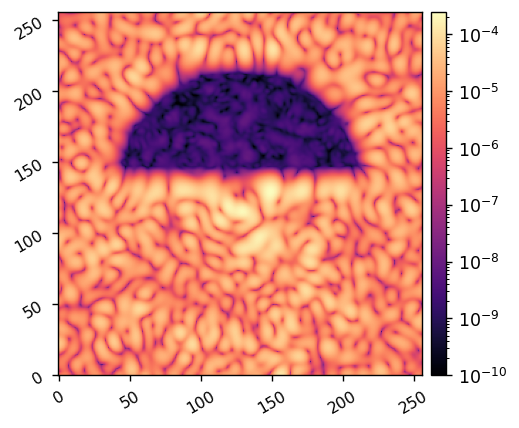

In [11]:
imshow1(total_im, lognorm=True, vmin=1e-10)

In [15]:
xp.mean(total_im[control_mask.astype(bool)])

array(1.93894483e-09)